# 04 — TSP Instance Loader and Distance Matrix

**Maps to:** `report/Chapters/Task1.tex` §`T1:Benchmark`.  
**Ticket:** TICKET-04.

Parse the chosen TSPLIB file, return `(coords, dist_matrix)`. Verify dimensions match the benchmark spec.

In [7]:
import math

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tsplib95



PALETTE = "Set2"
%matplotlib inline
sns.set(style='white', context='notebook', palette=PALETTE, rc={'figure.figsize':(14,10)})

## Implementation

This function load and parses TSPLIB files into a coordinate array and precomputed Euclidian matrix.

In [8]:
def load_tsp(path):
    """Parse a TSPLIB file and return (coords, dist_matrix).

    coords:      ndarray of shape (n, 2) — city coordinates in node order.
    dist_matrix: ndarray of shape (n, n) — full Euclidean distance matrix (float64).
    """
    problem = tsplib95.load(str(path))
    nodes = list(problem.get_nodes())

    coords = np.array(
        [problem.node_coords[node] for node in nodes], 
        dtype=np.float64
    )

    diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
    dist_matrix = np.sqrt((diff**2).sum(axis=-1))

    return coords, dist_matrix

## Unit Test — 4-City Square

To verify the correctness of this implementation, we add a sample case of a square with corners at (0,0), (1,0), (1,1), (0,1). This square will have the following properties:

- Side length = $1$
- Diagonal = $\sqrt{2}$

In [9]:
coords_test, dist_test = load_tsp("../data/TSP-dataset/kroA100.tsp")

# Quick inline test on a hand-built case instead of relying on a .tsp fixture.
# Build a 4-city square manually and verify the distance matrix.
square_coords = np.array([
    [0, 0], 
    [1, 0], 
    [1, 1], 
    [0, 1]], 
dtype=np.float64)
diff = square_coords[:, np.newaxis, :] - square_coords[np.newaxis, :, :]
square_dist = np.sqrt((diff**2).sum(axis=-1))

In [10]:
assert square_dist.shape == (4, 4), f"Expected (4,4), got {square_dist.shape}"
assert np.allclose(np.diag(square_dist), 0.0), "Diagonal should be zero"
assert np.allclose(square_dist, square_dist.T), "Should be symmetric"
assert math.isclose(square_dist[0, 1], 1.0), f"Side should be 1.0, got {square_dist[0,1]}"
assert math.isclose(square_dist[0, 2], math.sqrt(2)), f"Diagonal should be √2, got {square_dist[0,2]}"
assert math.isclose(square_dist[0, 3], 1.0), f"Side should be 1.0, got {square_dist[0,3]}"

print("Unit test passed: 4-city square distance matrix is correct.")

Unit test passed: 4-city square distance matrix is correct.


## Verify on kroA100

Load the chosen benchmark and confirm dimensions and matrix properties.

In [11]:
coords, dist_matrix = load_tsp("../data/TSP-dataset/kroA100.tsp")

print(f"Coordinates shape : {coords.shape}")
print(f"Distance matrix   : {dist_matrix.shape}")
print(f"Symmetric         : {np.allclose(dist_matrix, dist_matrix.T)}")
print(f"Diagonal all zero : {np.allclose(np.diag(dist_matrix), 0)}")
print(f"Min nonzero dist  : {dist_matrix[dist_matrix > 0].min():.2f}")
print(f"Max dist          : {dist_matrix.max():.2f}")

assert coords.shape == (100, 2), f"Expected (100,2), got {coords.shape}"
assert dist_matrix.shape == (100, 100), f"Expected (100,100), got {dist_matrix.shape}"

print("\nkroA100 loaded and verified.")

Coordinates shape : (100, 2)
Distance matrix   : (100, 100)
Symmetric         : True
Diagonal all zero : True
Min nonzero dist  : 13.04
Max dist          : 4149.78

kroA100 loaded and verified.


## Scatter Plot of Cities

Sanity-check the loader visually. Save figure to `results/figures/` for Task1.

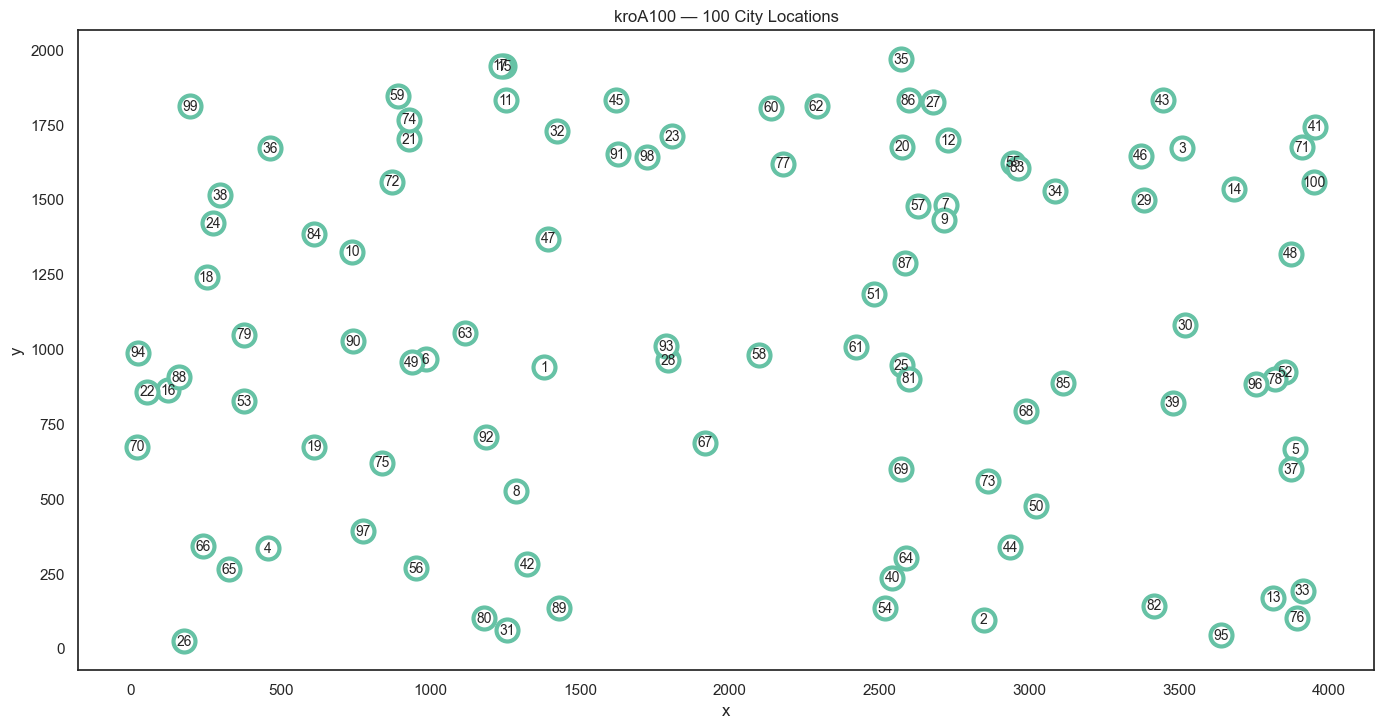

In [12]:
fig, ax = plt.subplots()

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    s=250,
    c="white",
    edgecolors=sns.color_palette("Set2")[0],
    linewidths=3,
    zorder=2,
)

for i, (x, y) in enumerate(coords):
    ax.text(x, y, str(i + 1), fontsize=10, ha="center", va="center", zorder=3)

ax.set_title("kroA100 — 100 City Locations")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.tight_layout()
fig.savefig("../results/figures/kroA100_cities.pdf", bbox_inches="tight")
fig.savefig("../results/figures/kroA100_cities.png", dpi=150, bbox_inches="tight")
plt.show()